In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error


In [4]:
df = pd.read_excel("merged_file.xlsx")


In [118]:
df["RECEIVED_DATE"] = pd.to_datetime(df["RECEIVED_DATE"])
df["DECISION_DATE"] = pd.to_datetime(df["DECISION_DATE"])

df["days"] = (df["DECISION_DATE"] - df["RECEIVED_DATE"]).dt.days

df = df.dropna(subset=["days"])


features = ["JOB_TITLE", "PRIMARY_WORKSITE_STATE","PRIMARY_WORKSITE_CITY","JOB_OPP_WAGE_FROM","OCCUPATION_TYPE","EMP_BUSINESS_NAME","EMP_POC_LAST_NAME","EMP_POC_JOB_TITLE","NOTICE_POST_BARGAIN_REP_PHYSICAL","NOTICE_POST_BARGAIN_REP_ELECTRONIC","NOTICE_POST_BARGAIN_REP_INHOUSE","NOTICE_POST_BARGAIN_REP_PRIVATE",]   # change based on your dataset
target = "days"

X = df[features]
y = df[target]


In [119]:
y

,days
0,493
1,493
2,493
3,493
4,493
...,...
165209,40
165210,469
165211,469
165212,29


KNN


In [120]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error


df["RECEIVED_DATE"] = pd.to_datetime(df["RECEIVED_DATE"])
df["DECISION_DATE"] = pd.to_datetime(df["DECISION_DATE"])

df["days"] = (df["DECISION_DATE"] - df["RECEIVED_DATE"]).dt.days


df = df.dropna(subset=["days"])


features = ["JOB_TITLE", "PRIMARY_WORKSITE_STATE","PRIMARY_WORKSITE_CITY","JOB_OPP_WAGE_FROM","OCCUPATION_TYPE","EMP_BUSINESS_NAME","EMP_POC_LAST_NAME","EMP_POC_JOB_TITLE","NOTICE_POST_BARGAIN_REP_PHYSICAL","NOTICE_POST_BARGAIN_REP_ELECTRONIC","NOTICE_POST_BARGAIN_REP_INHOUSE","NOTICE_POST_BARGAIN_REP_PRIVATE",]   # change based on your dataset


target = "days"

X = df[features].copy()
y = df[target]


label_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X.loc[:, col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


predictions = knn.predict(X_test_scaled)


mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 35.54103440970856


In [121]:
from sklearn.metrics import r2_score
score = r2_score(y_test, predictions)
print("score :",score)

score : 0.07233403973324248


SVM


In [ ]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)


predictions = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error:33.5

In [70]:

label_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X.loc[:, col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [71]:
label_encoders

{'JOB_TITLE': LabelEncoder(),
 'PRIMARY_WORKSITE_STATE': LabelEncoder(),
 'PRIMARY_WORKSITE_CITY': LabelEncoder(),
 'OCCUPATION_TYPE': LabelEncoder(),
 'EMP_BUSINESS_NAME': LabelEncoder(),
 'EMP_POC_LAST_NAME': LabelEncoder(),
 'EMP_POC_JOB_TITLE': LabelEncoder(),
 'NOTICE_POST_BARGAIN_REP_PHYSICAL': LabelEncoder(),
 'NOTICE_POST_BARGAIN_REP_ELECTRONIC': LabelEncoder(),
 'NOTICE_POST_BARGAIN_REP_INHOUSE': LabelEncoder(),
 'NOTICE_POST_BARGAIN_REP_PRIVATE': LabelEncoder()}

In [76]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_imputed, y_train)
X_test_imputed = imputer.transform(X_test)
predictions = model.predict(X_test_imputed)

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 36.40261179268259


In [77]:
from sklearn.metrics import r2_score
score = r2_score(y_test, predictions)
print("score :",score)

score : 0.0023641198676088715


#Correlation


In [78]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                         EMP_NUM_PAYROLL  JOB_OPP_WAGE_FROM  JOB_OPP_WAGE_TO  \
EMP_NUM_PAYROLL                 1.000000           0.117610         0.008020   
JOB_OPP_WAGE_FROM               0.117610           1.000000         0.065856   
JOB_OPP_WAGE_TO                 0.008020           0.065856         1.000000   
PRIMARY_WORKSITE_COUNTY              NaN                NaN              NaN   
days                            0.006556          -0.019135        -0.009893   

                         PRIMARY_WORKSITE_COUNTY      days  
EMP_NUM_PAYROLL                              NaN  0.006556  
JOB_OPP_WAGE_FROM                            NaN -0.019135  
JOB_OPP_WAGE_TO                              NaN -0.009893  
PRIMARY_WORKSITE_COUNTY                      NaN       NaN  
days                                         NaN  1.000000  


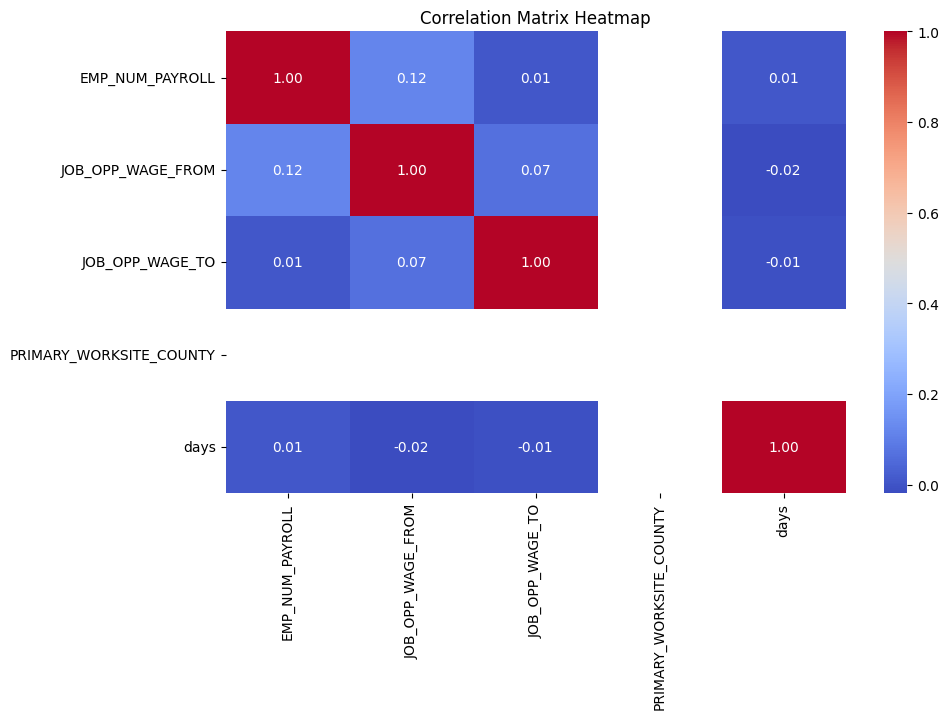

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [80]:
X

,JOB_TITLE,PRIMARY_WORKSITE_STATE,PRIMARY_WORKSITE_CITY,JOB_OPP_WAGE_FROM,OCCUPATION_TYPE,EMP_BUSINESS_NAME,EMP_POC_LAST_NAME,EMP_POC_JOB_TITLE,NOTICE_POST_BARGAIN_REP_PHYSICAL,NOTICE_POST_BARGAIN_REP_ELECTRONIC,NOTICE_POST_BARGAIN_REP_INHOUSE,NOTICE_POST_BARGAIN_REP_PRIVATE
0,16209,2,7060,19635.0,1,28325,18603,5650,1,0,0,0
1,16209,2,7060,19635.0,1,28325,18603,5650,1,0,0,0
2,16209,2,7060,19635.0,1,28325,18603,5650,1,0,0,0
3,16209,2,7060,19635.0,1,28325,18603,5650,1,0,0,0
4,16209,2,7060,19635.0,1,28325,18603,5650,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
165209,25101,13,7628,108722.0,3,24581,8873,2656,1,0,0,0
165210,19322,14,1971,120476.0,3,38464,16834,11548,1,0,1,0
165211,2662,9,4865,119933.0,3,38464,16834,11548,1,0,1,0
165212,25101,13,7628,108722.0,3,24581,8873,2656,1,0,0,0


In [81]:
corr_with_target = corr_matrix["days"].sort_values(ascending=False)
print(corr_with_target)

days                       1.000000
EMP_NUM_PAYROLL            0.006556
JOB_OPP_WAGE_TO           -0.009893
JOB_OPP_WAGE_FROM         -0.019135
PRIMARY_WORKSITE_COUNTY         NaN
Name: days, dtype: float64


In [82]:
df_model.head()

,PRIMARY_WORKSITE_STATE,PRIMARY_WORKSITE_CITY,JOB_OPP_WAGE_FROM,OCCUPATION_TYPE,EMP_POC_LAST_NAME,EMP_POC_JOB_TITLE,NOTICE_POST_BARGAIN_REP_PHYSICAL,NOTICE_POST_BARGAIN_REP_INHOUSE,days
0,2,7060,19635.0,1,18603,5650,1,0,493
1,2,7060,19635.0,1,18603,5650,1,0,493
2,2,7060,19635.0,1,18603,5650,1,0,493
3,2,7060,19635.0,1,18603,5650,1,0,493
4,2,7060,19635.0,1,18603,5650,1,0,493


In [83]:
corr_matrix = df_model.corr()
corr_matrix

,PRIMARY_WORKSITE_STATE,PRIMARY_WORKSITE_CITY,JOB_OPP_WAGE_FROM,OCCUPATION_TYPE,EMP_POC_LAST_NAME,EMP_POC_JOB_TITLE,NOTICE_POST_BARGAIN_REP_PHYSICAL,NOTICE_POST_BARGAIN_REP_INHOUSE,days
PRIMARY_WORKSITE_STATE,1.000000,0.143710,0.065432,0.110787,-0.081363,0.069357,-0.031603,0.081957,-0.010201
PRIMARY_WORKSITE_CITY,0.143710,1.000000,0.001817,-0.023932,-0.046858,-0.016709,0.018470,0.018809,-0.005541
JOB_OPP_WAGE_FROM,0.065432,0.001817,1.000000,0.501278,-0.051909,0.116041,0.057785,0.334061,-0.019135
OCCUPATION_TYPE,0.110787,-0.023932,0.501278,1.000000,-0.080475,0.116874,0.101116,0.428968,-0.016686
EMP_POC_LAST_NAME,-0.081363,-0.046858,-0.051909,-0.080475,1.000000,-0.049360,-0.000515,-0.097009,-0.005382
EMP_POC_JOB_TITLE,0.069357,-0.016709,0.116041,0.116874,-0.049360,1.000000,-0.001275,0.138677,-0.010147
NOTICE_POST_BARGAIN_REP_PHYSICAL,-0.031603,0.018470,0.057785,0.101116,-0.000515,-0.001275,1.000000,0.094437,0.035141
NOTICE_POST_BARGAIN_REP_INHOUSE,0.081957,0.018809,0.334061,0.428968,-0.097009,0.138677,0.094437,1.000000,-0.008720
days,-0.010201,-0.005541,-0.019135,-0.016686,-0.005382,-0.010147,0.035141,-0.008720,1.000000


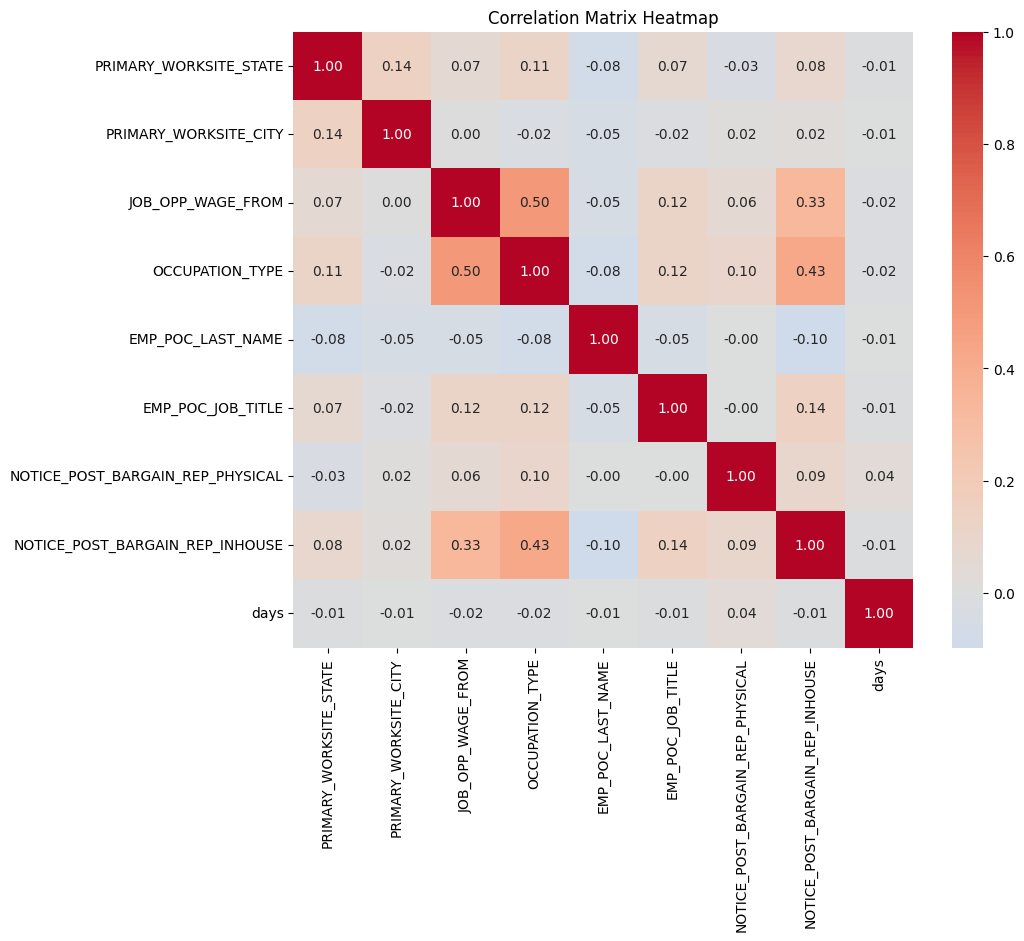

In [84]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            center=0)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [85]:
X = X.drop(columns=["NOTICE_POST_BARGAIN_REP_PRIVATE","NOTICE_POST_BARGAIN_REP_ELECTRONIC","EMP_BUSINESS_NAME"])

In [86]:
X = X.drop(columns=["JOB_TITLE"])

In [87]:
X

,PRIMARY_WORKSITE_STATE,PRIMARY_WORKSITE_CITY,JOB_OPP_WAGE_FROM,OCCUPATION_TYPE,EMP_POC_LAST_NAME,EMP_POC_JOB_TITLE,NOTICE_POST_BARGAIN_REP_PHYSICAL,NOTICE_POST_BARGAIN_REP_INHOUSE
0,2,7060,19635.0,1,18603,5650,1,0
1,2,7060,19635.0,1,18603,5650,1,0
2,2,7060,19635.0,1,18603,5650,1,0
3,2,7060,19635.0,1,18603,5650,1,0
4,2,7060,19635.0,1,18603,5650,1,0
...,...,...,...,...,...,...,...,...
165209,13,7628,108722.0,3,8873,2656,1,0
165210,14,1971,120476.0,3,16834,11548,1,1
165211,9,4865,119933.0,3,16834,11548,1,1
165212,13,7628,108722.0,3,8873,2656,1,0


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.isnull().sum())
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

PRIMARY_WORKSITE_STATE               0
PRIMARY_WORKSITE_CITY                0
JOB_OPP_WAGE_FROM                   90
OCCUPATION_TYPE                      0
EMP_POC_LAST_NAME                    0
EMP_POC_JOB_TITLE                    0
NOTICE_POST_BARGAIN_REP_PHYSICAL     0
NOTICE_POST_BARGAIN_REP_INHOUSE      0
dtype: int64


/tmp/ipykernel_8350/2486997975.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.fillna(0)
/tmp/ipykernel_8350/2486997975.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.fillna(0)


In [89]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 36.4017802423833


In [90]:
X

,PRIMARY_WORKSITE_STATE,PRIMARY_WORKSITE_CITY,JOB_OPP_WAGE_FROM,OCCUPATION_TYPE,EMP_POC_LAST_NAME,EMP_POC_JOB_TITLE,NOTICE_POST_BARGAIN_REP_PHYSICAL,NOTICE_POST_BARGAIN_REP_INHOUSE
0,2,7060,19635.0,1,18603,5650,1,0
1,2,7060,19635.0,1,18603,5650,1,0
2,2,7060,19635.0,1,18603,5650,1,0
3,2,7060,19635.0,1,18603,5650,1,0
4,2,7060,19635.0,1,18603,5650,1,0
...,...,...,...,...,...,...,...,...
165209,13,7628,108722.0,3,8873,2656,1,0
165210,14,1971,120476.0,3,16834,11548,1,1
165211,9,4865,119933.0,3,16834,11548,1,1
165212,13,7628,108722.0,3,8873,2656,1,0


#PCA

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (132171, 8)
Reduced shape: (132171, 5)


In [93]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_pca, y_train)

predictions = model.predict(X_test_pca)

In [106]:
new_sample = {
    "PRIMARY_WORKSITE_STATE": ["NY"],
    "PRIMARY_WORKSITE_CITY": ["NEW YORK"],
    "JOB_OPP_WAGE_FROM": [150000.0],
    "OCCUPATION_TYPE": ["MANAGEMENT ANALYST"],
    "EMP_POC_LAST_NAME": ["DOE"],
    "EMP_POC_JOB_TITLE": ["SENIOR MANAGER"],
    "NOTICE_POST_BARGAIN_REP_PHYSICAL": [0],
    "NOTICE_POST_BARGAIN_REP_INHOUSE": [1]
}

new_df = pd.DataFrame(new_sample)

categorical_cols_to_encode = [
    "PRIMARY_WORKSITE_STATE",
    "PRIMARY_WORKSITE_CITY",
    "OCCUPATION_TYPE",
    "EMP_POC_LAST_NAME",
    "EMP_POC_JOB_TITLE"
]

for col in categorical_cols_to_encode:
    if col in label_encoders and col in new_df.columns:
        sample_value = new_df[col].iloc[0]
        if sample_value in label_encoders[col].classes_:
            new_df.loc[:, col] = label_encoders[col].transform(new_df[col].astype(str))
        else:
            print(f"Warning: Category '{sample_value}' for column '{col}' not seen during training. Assigning -1.")
            new_df.loc[:, col] = -1

new_df = new_df.fillna(0)

current_X_columns = X.columns.tolist()
new_df = new_df[current_X_columns]

new_scaled = scaler.transform(new_df)
new_pca    = pca.transform(new_scaled)
predicted_days = model.predict(new_pca)

print("Predicted days:", predicted_days[0])

Predicted days: 457.5058003904394


/tmp/ipykernel_8350/2354348980.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df = new_df.fillna(0)


In [108]:
print("Variance retained:", sum(pca.explained_variance_ratio_))

Variance retained: 0.7625358209334135


In [96]:
print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 0.0022459124389386798


In [8]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

df["RECEIVED_DATE"] = pd.to_datetime(df["RECEIVED_DATE"])
df["DECISION_DATE"] = pd.to_datetime(df["DECISION_DATE"])
df["days"] = (df["DECISION_DATE"] - df["RECEIVED_DATE"]).dt.days
df = df.dropna(subset=["days"])

features = [
    "PRIMARY_WORKSITE_STATE",
    "PRIMARY_WORKSITE_CITY",
    "JOB_OPP_WAGE_FROM",
    "OCCUPATION_TYPE",
    "EMP_POC_LAST_NAME",
    "EMP_POC_JOB_TITLE",
    "NOTICE_POST_BARGAIN_REP_PHYSICAL",
    "NOTICE_POST_BARGAIN_REP_INHOUSE",
]
target = "days"

X = df[features].copy()
y = df[target]

binary_cols = [
    "NOTICE_POST_BARGAIN_REP_PHYSICAL",
    "NOTICE_POST_BARGAIN_REP_INHOUSE",
]
for col in binary_cols:
    if col in X.columns:
        X[col] = X[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)


categorical_cols = [
    "PRIMARY_WORKSITE_STATE",
    "PRIMARY_WORKSITE_CITY",
    "OCCUPATION_TYPE",
    "EMP_POC_LAST_NAME",
    "EMP_POC_JOB_TITLE",
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"Variance retained by PCA: {sum(pca.explained_variance_ratio_):.2%}")

model = LinearRegression()
model.fit(X_train_pca, y_train)

predictions = model.predict(X_test_pca)
mae   = mean_absolute_error(y_test, predictions)
score = r2_score(y_test, predictions)
print(f"MAE:      {mae:.2f} days")
print(f"R² Score: {score:.4f}")


def predict_days(
    state: str,
    city: str,
    wage: float,
    occupation_type: str,
    poc_last_name: str,
    poc_job_title: str,
    notice_physical: int,
    notice_inhouse: int,
) -> float:
    """
    Predict visa processing days for a single applicant.

    Parameters
    ----------
    state            : e.g. "CA"
    city             : e.g. "SAN FRANCISCO"
    wage             : annual wage from job opportunity, e.g. 120000.0
    occupation_type  : e.g. "COMPUTER SYSTEMS ANALYST"
    poc_last_name    : employer point-of-contact last name, e.g. "SMITH"
    poc_job_title    : employer POC job title, e.g. "HR MANAGER"
    notice_physical  : 0 or 1 — bargaining rep physical notice posted
    notice_inhouse   : 0 or 1 — bargaining rep in-house notice posted

    Returns
    -------
    Predicted number of days (float)
    """
    sample = {
        "PRIMARY_WORKSITE_STATE": [state.upper()],
        "PRIMARY_WORKSITE_CITY":  [city.upper()],
        "JOB_OPP_WAGE_FROM":      [float(wage)],
        "OCCUPATION_TYPE":        [occupation_type.upper()],
        "EMP_POC_LAST_NAME":      [poc_last_name.upper()],
        "EMP_POC_JOB_TITLE":      [poc_job_title.upper()],
        "NOTICE_POST_BARGAIN_REP_PHYSICAL": [int(notice_physical)],
        "NOTICE_POST_BARGAIN_REP_INHOUSE":  [int(notice_inhouse)],
    }
    new_df = pd.DataFrame(sample)

    for col in categorical_cols:
        val = new_df[col].iloc[0]
        if val in label_encoders[col].classes_:
            new_df[col] = label_encoders[col].transform(new_df[col].astype(str))
        else:
            print(f"  ⚠  '{val}' not seen during training for '{col}'. Using -1.")
            new_df[col] = -1

    new_df = new_df.fillna(0)
    new_df = new_df[features]

    new_scaled = scaler.transform(new_df)
    new_pca    = pca.transform(new_scaled)
    result     = model.predict(new_pca)
    return float(result[0])



Variance retained by PCA: 75.22%
MAE:      36.37 days
R² Score: 0.0024
